In [4]:
import requests
import pandas as pd
from pytrends.request import TrendReq
from datetime import datetime
from dateutil.relativedelta import relativedelta
import time
import matplotlib.pyplot as plt



url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_manr"

params = {
    "geo": "DE",
    "coicop": "CP00",
    "unit": "RCH_A"
}

r = requests.get(url, params=params)
data = r.json()

time_index = data["dimension"]["time"]["category"]["index"]
values = data["value"]

rows = []

for date, idx in time_index.items():
    value = values.get(str(idx))
    rows.append({
        "month": date,
        "inflation_rate": value
    })

df_inflation = pd.DataFrame(rows)

df_inflation["month"] = pd.to_datetime(df_inflation["month"])

df_inflation = df_inflation.sort_values("month")



In [5]:
# nur 2024 bis 2025 behalten
df_2024_2025 = df_inflation[
    (df_inflation["month"] >= "2022-01-01") &
    (df_inflation["month"] <= "2024-12-31")
]

df_over_5 = df_inflation[df_inflation['inflation_rate'] > 5.0]
df_2024_2025



,month,inflation_rate
300,2022-01-01,5.1
301,2022-02-01,5.5
302,2022-03-01,7.6
303,2022-04-01,7.8
304,2022-05-01,8.7
305,2022-06-01,8.2
306,2022-07-01,8.5
307,2022-08-01,8.8
308,2022-09-01,10.9
309,2022-10-01,11.6


In [6]:
from pytrends.request import TrendReq
import pandas as pd

pytrends = TrendReq(hl="de-DE", tz=360)

keywords = ["Inflation", "Energiekosten", "Lebenshaltungskosten"]

dfs = []

for word in keywords:

    pytrends.build_payload([word], timeframe="2022-01-01 2023-12-31", geo="DE")

    df = pytrends.interest_over_time()

    df = df.drop(columns=["isPartial"])

    dfs.append(df)

# Daten zusammenführen
trends = pd.concat(dfs, axis=1)

trends.head()


,Inflation,Energiekosten,Lebenshaltungskosten
date,,,
2021-12-26,43,8,64
2022-01-02,66,11,88
2022-01-09,66,12,73
2022-01-16,54,13,78
2022-01-23,56,13,75


In [9]:
trends = trends.reset_index()
trends.columns

Index(['date', 'Inflation', 'Energiekosten', 'Lebenshaltungskosten'], dtype='object')

In [10]:
trends["month"] = trends["date"].dt.to_period("M")
trends_monthly = trends.groupby("month").mean(numeric_only=True)
trends_monthly
trends_monthly = trends_monthly.reset_index()
trends_monthly

,month,Inflation,Energiekosten,Lebenshaltungskosten
0,2021-12,43.00,8.00,64.00
1,2022-01,61.20,13.20,78.60
2,2022-02,59.75,14.50,79.00
3,2022-03,73.25,47.75,85.50
4,2022-04,72.25,25.00,81.00
5,2022-05,73.00,21.00,72.80
6,2022-06,82.00,21.50,76.50
7,2022-07,70.80,29.40,82.00
8,2022-08,74.75,44.75,85.75
9,2022-09,92.75,60.00,75.50


In [11]:

# Min-Max Normalisierung (empfohlen für Visualisierung)

trends_scaled = trends.copy()

for col in ["Inflation", "Energiekosten", "Lebenshaltungskosten"]:
    trends_scaled[col] = (
        trends[col] - trends[col].min()
    ) / (trends[col].max() - trends[col].min())

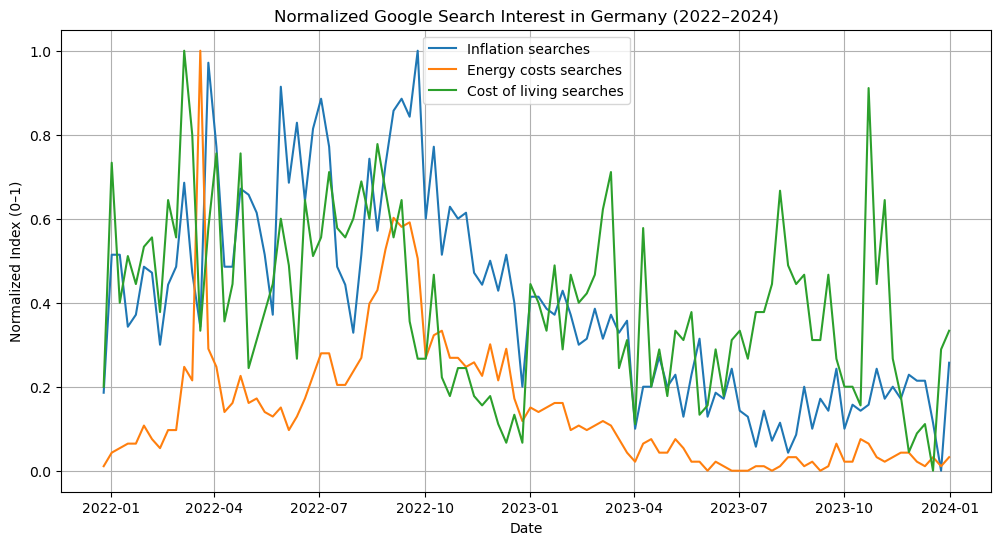

In [12]:

plt.figure(figsize=(12,6))

plt.plot(trends_scaled["date"], trends_scaled["Inflation"], label="Inflation searches")
plt.plot(trends_scaled["date"], trends_scaled["Energiekosten"], label="Energy costs searches")
plt.plot(trends_scaled["date"], trends_scaled["Lebenshaltungskosten"], label="Cost of living searches")

plt.legend()
plt.title("Normalized Google Search Interest in Germany (2022–2024)")
plt.xlabel("Date")
plt.ylabel("Normalized Index (0–1)")
plt.grid(True)

plt.show()

In [31]:
df_inflation["month"] = pd.to_datetime(df_inflation["month"])
trends_monthly["month"] = pd.to_datetime(trends_monthly["month"])

rates_and_searches = pd.merge(
    df_2024_2025,
    trends_monthly,
    on="month",
    how="inner"
)

rates_and_searches

,month,inflation_rate,Inflation,Energiekosten,Lebenshaltungskosten
0,2022-01-01,5.1,61.20,13.20,78.60
1,2022-02-01,5.5,59.75,14.50,79.00
2,2022-03-01,7.6,73.25,47.75,85.50
3,2022-04-01,7.8,72.25,25.00,81.00
4,2022-05-01,8.7,73.00,21.00,72.80
5,2022-06-01,8.2,82.00,21.50,76.50
6,2022-07-01,8.5,70.80,29.40,82.00
7,2022-08-01,8.8,74.75,44.75,85.75
8,2022-09-01,10.9,92.75,60.00,75.50
9,2022-10-01,11.6,73.60,34.20,67.40


In [32]:

API_KEY = "f594fecb9eec968ed0337cfe19b5c18c"
BASE_URL = "https://gnews.io/api/v4/search"

QUERY = "inflation OR Teuerung"
COUNTRY = "de"
LANG = "de"

start = datetime(2022, 1, 1)
end   = datetime(2024, 1, 1)  

rows = []
cur = start

while cur < end:
    nxt = cur + relativedelta(months=1)

    params = {
        "q": QUERY,
        "country": COUNTRY,
        "lang": LANG,
        # ISO 8601 mit Z (wichtig!)
        "from": cur.strftime("%Y-%m-%dT00:00:00Z"),
        "to":   (nxt - relativedelta(days=1)).strftime("%Y-%m-%dT23:59:59Z"),
        "max": 1,      # nur 1 Artikel; wir nutzen totalArticles als Count
        "page": 1,
        "apikey": API_KEY
    }

    r = requests.get(BASE_URL, params=params, timeout=30)

    if r.status_code == 429:
        print("429 -> warte 60s und versuche den Monat nochmal:", cur.strftime("%Y-%m"))
        time.sleep(60)
        continue

    r.raise_for_status()
    data = r.json()

    total = data.get("totalArticles")
    print("OK", cur.strftime("%Y-%m"), "from/to:", params["from"], params["to"], "news_count:", total)

    rows.append({"month": cur.strftime("%Y-%m-01"), "news_count": total})

    cur = nxt
    time.sleep(1.2)  # GNews: i.d.R. max ~1 request/sec im Free Plan

news_monthly = pd.DataFrame(rows)
news_monthly["month"] = pd.to_datetime(news_monthly["month"])

news_monthly.to_csv("gnews_monthly_inflation_DE_2022_2023.csv", index=False)
news_monthly.head()

OK 2022-01 from/to: 2022-01-01T00:00:00Z 2022-01-31T23:59:59Z news_count: 312
OK 2022-02 from/to: 2022-02-01T00:00:00Z 2022-02-28T23:59:59Z news_count: 267
OK 2022-03 from/to: 2022-03-01T00:00:00Z 2022-03-31T23:59:59Z news_count: 331
OK 2022-04 from/to: 2022-04-01T00:00:00Z 2022-04-30T23:59:59Z news_count: 372
OK 2022-05 from/to: 2022-05-01T00:00:00Z 2022-05-31T23:59:59Z news_count: 566
OK 2022-06 from/to: 2022-06-01T00:00:00Z 2022-06-30T23:59:59Z news_count: 729
OK 2022-07 from/to: 2022-07-01T00:00:00Z 2022-07-31T23:59:59Z news_count: 722
OK 2022-08 from/to: 2022-08-01T00:00:00Z 2022-08-31T23:59:59Z news_count: 649
OK 2022-09 from/to: 2022-09-01T00:00:00Z 2022-09-30T23:59:59Z news_count: 777
OK 2022-10 from/to: 2022-10-01T00:00:00Z 2022-10-31T23:59:59Z news_count: 682
OK 2022-11 from/to: 2022-11-01T00:00:00Z 2022-11-30T23:59:59Z news_count: 733
OK 2022-12 from/to: 2022-12-01T00:00:00Z 2022-12-31T23:59:59Z news_count: 524
OK 2023-01 from/to: 2023-01-01T00:00:00Z 2023-01-31T23:59:59Z ne

,month,news_count
0,2022-01-01,312
1,2022-02-01,267
2,2022-03-01,331
3,2022-04-01,372
4,2022-05-01,566


In [33]:
news_monthly

,month,news_count
0,2022-01-01,312
1,2022-02-01,267
2,2022-03-01,331
3,2022-04-01,372
4,2022-05-01,566
5,2022-06-01,729
6,2022-07-01,722
7,2022-08-01,649
8,2022-09-01,777
9,2022-10-01,682


In [34]:

rates_and_searches["month"] = pd.to_datetime(rates_and_searches["month"]).dt.to_period("M").dt.to_timestamp()
news_monthly["month"] = pd.to_datetime(news_monthly["month"]).dt.to_period("M").dt.to_timestamp()

In [36]:
final_data = rates_and_searches.merge(news_monthly, on="month", how="inner")
final_data

,month,inflation_rate,Inflation,Energiekosten,Lebenshaltungskosten,news_count
0,2022-01-01,5.1,61.20,13.20,78.60,312
1,2022-02-01,5.5,59.75,14.50,79.00,267
2,2022-03-01,7.6,73.25,47.75,85.50,331
3,2022-04-01,7.8,72.25,25.00,81.00,372
4,2022-05-01,8.7,73.00,21.00,72.80,566
5,2022-06-01,8.2,82.00,21.50,76.50,729
6,2022-07-01,8.5,70.80,29.40,82.00,722
7,2022-08-01,8.8,74.75,44.75,85.75,649
8,2022-09-01,10.9,92.75,60.00,75.50,777
9,2022-10-01,11.6,73.60,34.20,67.40,682
